# Notebook 1: Raw Data EDA and Cleaning

**Purpose:** Unsupervised Exploratory Data Analysis (EDA) on the full dataset, data quality checks, and sample validation.

**Actions:**
- **Full Dataset EDA:** Look at global distributions, long-tail item popularity, overall seasonal trends, and missing data patterns across the entire population. This informs temporal framing and negative sampling strategies.
- **Sample Validation:** Compare the distributions (e.g., age, price, category popularity) of the sampled data against the full dataset to ensure the sample is truly representative and hasn't introduced bias.
- Define strategies for missing values, outliers, and category grouping based on these observations.

*Note: This notebook uses Pandas for data manipulation and analysis.*

## 1. Setup and Imports

In this section, we import the necessary Python libraries for data manipulation and visualization.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add notebooks/ to sys.path so utils/ is importable without installing the package
for _nb in (Path.cwd(), Path.cwd() / "notebooks", Path.cwd().parent / "notebooks"):
    if (_nb / "utils").is_dir():
        sys.path[:0] = [str(_nb)]
        break

from utils.data_casting import cast_table, save_parquet, save_parquet_hive

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Define Data Paths

Next, we define the file paths for the full dataset (CSVs) and the sampled dataset (Parquet files).

In [2]:
def find_repo_root() -> Path:
    """Locate repository root (contains configs/). Works from repo root or notebooks/."""
    for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd() / "notebooks"):
        if (candidate / "configs").is_dir():
            return candidate
    return Path.cwd()


ACTIVE_DATASET = os.getenv("ACTIVE_DATASET", "sample_2000_users")
REPO_ROOT = find_repo_root()


def get_data_paths(dataset_name: str = ACTIVE_DATASET) -> dict:
    """
    Define and return the paths for the full and active dev-sample datasets.

    Args:
        dataset_name: Subfolder under dataset/ (e.g. ``dummy`` or ``sample_2000_users``).
            Override via ACTIVE_DATASET env var for smoke tests.

    Returns:
        dict: Paths to full CSVs and the active sample Parquet tables.
    """
    dataset_root = REPO_ROOT / "dataset"
    paths = {
        "full_articles": str(dataset_root / "full" / "articles.csv"),
        "full_customers": str(dataset_root / "full" / "customers.csv"),
        "full_transactions": str(dataset_root / "full" / "transactions_train.csv"),
        "sample_articles": str(dataset_root / dataset_name / "articles"),
        "sample_customers": str(dataset_root / dataset_name / "customers"),
        "sample_transactions": str(dataset_root / dataset_name / "transactions"),
        "active_dataset": dataset_name,
    }
    return paths

data_paths = get_data_paths()
print(f"Active dataset: {data_paths['active_dataset']}")

Active dataset: sample_2000_users


## 3. Load Full Dataset

We load the full dataset CSV files into Pandas DataFrames. To optimize memory usage, we specify data types for certain columns.

In [3]:
def load_full_data(paths: dict) -> tuple:
    """
    Load the full dataset from CSV files.
    
    Args:
        paths (dict): Dictionary containing file paths.
        
    Returns:
        tuple: (articles_df, customers_df, transactions_df)
    """
    print("Loading full articles...")
    articles_full = pd.read_csv(paths["full_articles"], dtype={'article_id': str})
    
    print("Loading full customers...")
    customers_full = pd.read_csv(paths["full_customers"], dtype={'customer_id': str, 'postal_code': str})
    
    print("Loading full transactions...")
    # Parse dates during load for transactions
    transactions_full = pd.read_csv(
        paths["full_transactions"], 
        dtype={'customer_id': str, 'article_id': str},
        parse_dates=['t_dat']
    )
    
    return articles_full, customers_full, transactions_full

articles_full, customers_full, transactions_full = load_full_data(data_paths)
print("Full data loaded successfully.")

Loading full articles...
Loading full customers...
Loading full transactions...
Full data loaded successfully.


## 4. Load Sampled Dataset

We load the sampled dataset from Parquet files to use later for sample validation against the full dataset.

In [4]:
def load_sampled_data(paths: dict) -> tuple:
    """
    Load the sampled dataset from Parquet files.
    
    Args:
        paths (dict): Dictionary containing file paths.
        
    Returns:
        tuple: (articles_sample, customers_sample, transactions_sample)
    """
    print("Loading sampled articles...")
    articles_sample = pd.read_parquet(paths["sample_articles"])
    
    print("Loading sampled customers...")
    customers_sample = pd.read_parquet(paths["sample_customers"])
    
    print("Loading sampled transactions...")
    transactions_sample = pd.read_parquet(paths["sample_transactions"])
    
    return articles_sample, customers_sample, transactions_sample

articles_sample, customers_sample, transactions_sample = load_sampled_data(data_paths)
print("Sampled data loaded successfully.")

Loading sampled articles...
Loading sampled customers...
Loading sampled transactions...
Sampled data loaded successfully.


---

## 5. Cast Types and Persist

Apply ML-specific Pandas dtypes defined in `configs/data/ml_types.yaml` to all six loaded DataFrames.

**Why:** Raw CSVs load with Pandas defaults (`int64`, `float64`, `object`) which waste memory and don't distinguish categorical from free-text columns. Parquet preserves dtypes on disk, so downstream notebooks (feature engineering, EDA, modeling) can load with correct types immediately.

**Outputs:**
- Full dataset → `dataset/full_casted/{articles,customers,transactions}.parquet` (new folder; original CSVs unchanged)
- Sampled dataset → `dataset/sample_2000_users/{articles,customers,transactions}/` (overwrite in place)

In [ ]:
def cast_and_persist_raw_data(
    articles_full: pd.DataFrame,
    customers_full: pd.DataFrame,
    transactions_full: pd.DataFrame,
    articles_sample: pd.DataFrame,
    customers_sample: pd.DataFrame,
    transactions_sample: pd.DataFrame,
) -> tuple:
    """
    Cast all six raw DataFrames to ML-appropriate Pandas dtypes and persist to Parquet.

    Dtype definitions come from configs/data/ml_types.yaml. The function handles
    two datasets:
      - Full dataset:    saved to dataset/full_casted/ (original CSVs unchanged)
      - Active dev sample: overwritten in place at dataset/{ACTIVE_DATASET}/

    save_parquet() resolves paths relative to the repo root (the directory that
    contains configs/), so paths here do not need the notebook-relative '../' prefix.

    Args:
        articles_full: Articles DataFrame loaded from full CSV.
        customers_full: Customers DataFrame loaded from full CSV.
        transactions_full: Transactions DataFrame loaded from full CSV.
        articles_sample: Articles DataFrame loaded from sampled Parquet.
        customers_sample: Customers DataFrame loaded from sampled Parquet.
        transactions_sample: Transactions DataFrame loaded from sampled Parquet.

    Returns:
        tuple: Six casted DataFrames in the same order as the arguments.
    """
    ML_TYPES_CONFIG = "configs/data/ml_types.yaml"

    # --- Full dataset → dataset/full_casted/ (new folder, CSVs untouched) ---
    print("Casting full articles...")
    articles_full = cast_table(articles_full, "articles", config_path=ML_TYPES_CONFIG)
    save_parquet(articles_full, "dataset/full_casted/articles.parquet")

    print("Casting full customers...")
    customers_full = cast_table(customers_full, "customers", config_path=ML_TYPES_CONFIG)
    save_parquet(customers_full, "dataset/full_casted/customers.parquet")

    print("Casting full transactions...")
    transactions_full = cast_table(transactions_full, "transactions", config_path=ML_TYPES_CONFIG)
    save_parquet(transactions_full, "dataset/full_casted/transactions.parquet")

    print("Full dataset casted → dataset/full_casted/")

    # --- Sampled dataset → overwrite in place (Hive Parquet layout, same as dummy) ---
    sample_root = f"dataset/{ACTIVE_DATASET}"
    print("Casting sampled articles...")
    articles_sample = cast_table(articles_sample, "articles", config_path=ML_TYPES_CONFIG)
    save_parquet_hive(articles_sample, f"{sample_root}/articles")

    print("Casting sampled customers...")
    customers_sample = cast_table(customers_sample, "customers", config_path=ML_TYPES_CONFIG)
    save_parquet_hive(customers_sample, f"{sample_root}/customers")

    print("Casting sampled transactions...")
    transactions_sample = cast_table(transactions_sample, "transactions", config_path=ML_TYPES_CONFIG)
    save_parquet_hive(
        transactions_sample,
        f"{sample_root}/transactions",
        partition_cols=["year", "month"],
    )

    print(f"Active dataset casted → {sample_root}/ (overwritten in place)")

    return (
        articles_full, customers_full, transactions_full,
        articles_sample, customers_sample, transactions_sample,
    )


(
    articles_full, customers_full, transactions_full,
    articles_sample, customers_sample, transactions_sample,
) = cast_and_persist_raw_data(
    articles_full, customers_full, transactions_full,
    articles_sample, customers_sample, transactions_sample,
)

print("\nDtype summary after casting:")
for name, df in [
    ("articles_full", articles_full),
    ("customers_full", customers_full),
    ("transactions_full", transactions_full),
    ("articles_sample", articles_sample),
    ("customers_sample", customers_sample),
    ("transactions_sample", transactions_sample),
]:
    print(f"\n{name}:\n{df.dtypes.to_string()}")

---

## 5. Full Dataset EDA (Unsupervised)

In this section, we explore the full dataset to understand its shape, data quality, missing values, and individual feature distributions.

### 5.1 Dataset Shape and Overview

Let's check the number of rows and columns for each table in the full dataset.

In [5]:
def print_dataset_shapes(articles: pd.DataFrame, customers: pd.DataFrame, transactions: pd.DataFrame) -> None:
    """
    Print the shape of the datasets.
    
    Args:
        articles (pd.DataFrame): Articles dataframe.
        customers (pd.DataFrame): Customers dataframe.
        transactions (pd.DataFrame): Transactions dataframe.
    """
    print("--- Dataset Shapes ---")
    print(f"Articles: {articles.shape[0]:,} rows, {articles.shape[1]} columns")
    print(f"Customers: {customers.shape[0]:,} rows, {customers.shape[1]} columns")
    print(f"Transactions: {transactions.shape[0]:,} rows, {transactions.shape[1]} columns")

print_dataset_shapes(articles_full, customers_full, transactions_full)

--- Dataset Shapes ---
Articles: 105,542 rows, 25 columns
Customers: 1,371,980 rows, 7 columns
Transactions: 31,788,324 rows, 5 columns


### 5.2 Data Quality and Missingness

We will calculate the percentage of missing values for each column in the datasets to identify which features need imputation or special handling.

In [6]:
def check_missing_values(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Calculate and display the percentage of missing values in a dataframe.
    
    Args:
        df (pd.DataFrame): The dataframe to analyze.
        name (str): Name of the dataframe for display purposes.
        
    Returns:
        pd.DataFrame: A dataframe containing columns with missing values and their percentages.
    """
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_pct})
    missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)
    
    print(f"\n--- Missing Values in {name} ---")
    if missing_df.empty:
        print("No missing values found.")
    else:
        print(missing_df)
        
    return missing_df

_ = check_missing_values(articles_full, "Articles")
_ = check_missing_values(customers_full, "Customers")
_ = check_missing_values(transactions_full, "Transactions")


--- Missing Values in Articles ---
             Missing Values  Percentage (%)
detail_desc             416        0.394156

--- Missing Values in Customers ---
                        Missing Values  Percentage (%)
Active                          907576       66.150819
FN                              895050       65.237831
fashion_news_frequency           16011        1.167000
age                              15861        1.156066
club_member_status                6062        0.441843

--- Missing Values in Transactions ---
No missing values found.


### 5.3 Individual Feature Distributions

Now we visualize the distributions of key features such as customer age, transaction prices, and article categories.

#### 5.3.1 Customer Age Distribution

Let's plot the distribution of customer ages to understand the demographic of the user base.

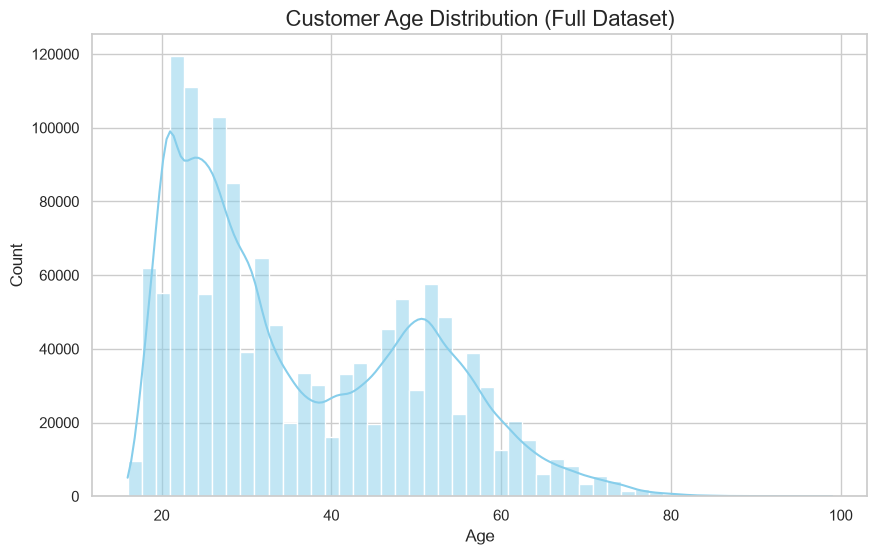

In [7]:
def plot_age_distribution(customers: pd.DataFrame) -> None:
    """
    Plot the distribution of customer ages.
    
    Args:
        customers (pd.DataFrame): Customers dataframe.
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(customers['age'].dropna(), bins=50, kde=True, color='skyblue')
    plt.title('Customer Age Distribution (Full Dataset)', fontsize=16)
    plt.xlabel('Age', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()

plot_age_distribution(customers_full)

**Insights & Recommendations:**
* **Insight:** The age distribution shows the demographic spread of the customer base, which may be skewed or bimodal (e.g., peaks at younger ages).
* **Recommendation:** As per the pre-processing guide, age is a critical query-side field for the two-tower model. We should cap implausible ages (e.g., below 16 or above 100), and apply z-score normalization using train-set mean and std. Decide on an explicit policy for missing ages (e.g., impute to a sentinel value or median).


#### 5.3.2 Transaction Price Distribution

We visualize the distribution of transaction prices. Since prices might be skewed, we will also look at a limited range to better understand the bulk of the data.

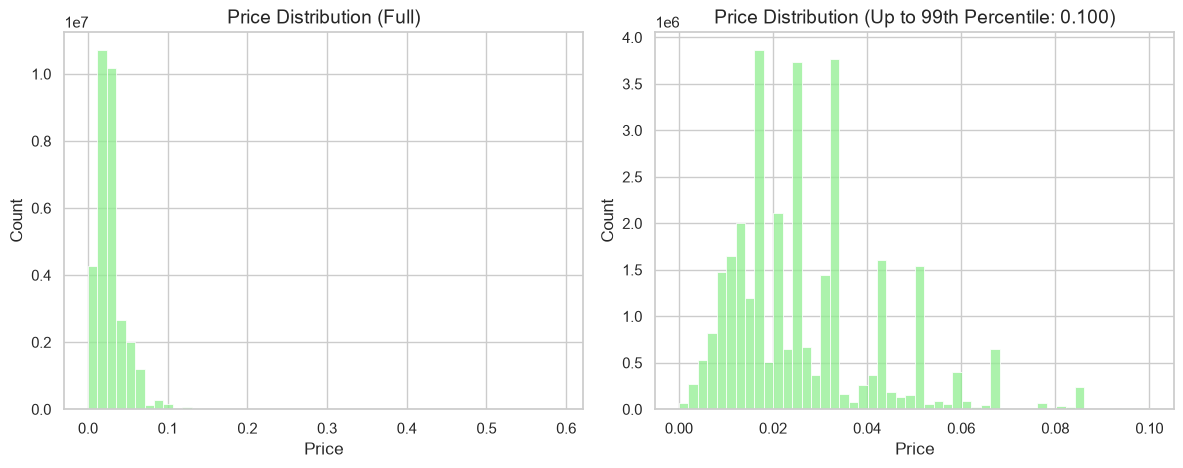

In [8]:
def plot_price_distribution(transactions: pd.DataFrame) -> None:
    """
    Plot the distribution of transaction prices.
    
    Args:
        transactions (pd.DataFrame): Transactions dataframe.
    """
    plt.figure(figsize=(12, 5))
    
    # Plot full distribution
    plt.subplot(1, 2, 1)
    sns.histplot(transactions['price'], bins=50, color='lightgreen')
    plt.title('Price Distribution (Full)', fontsize=14)
    plt.xlabel('Price')
    plt.ylabel('Count')
    
    # Plot zoomed distribution (e.g., up to 99th percentile)
    plt.subplot(1, 2, 2)
    p99 = transactions['price'].quantile(0.99)
    sns.histplot(transactions[transactions['price'] <= p99]['price'], bins=50, color='lightgreen')
    plt.title(f'Price Distribution (Up to 99th Percentile: {p99:.3f})', fontsize=14)
    plt.xlabel('Price')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()

plot_price_distribution(transactions_full)

**Insights & Recommendations:**
* **Insight:** Transaction prices are heavily skewed with extreme outliers in the long tail.
* **Recommendation:** Drop rows with null, zero, or negative prices. Winsorize transaction `price` at a high percentile (e.g., 99th) to reduce sensitivity to erroneous extreme prices before computing decayed price features.


#### 5.3.3 Article Category Popularity

Let's see which top-level article categories (index_group_name) are the most popular in the catalog.

C:\Users\rahul\AppData\Local\Temp\ipykernel_13588\2120049944.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')


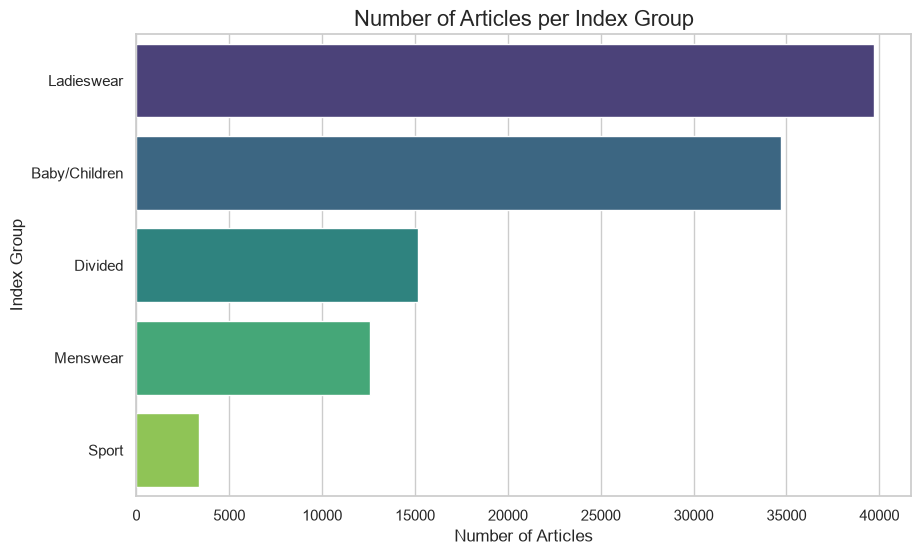

In [9]:
def plot_category_popularity(articles: pd.DataFrame) -> None:
    """
    Plot the count of articles per index group.
    
    Args:
        articles (pd.DataFrame): Articles dataframe.
    """
    plt.figure(figsize=(10, 6))
    # Count articles per index group
    cat_counts = articles['index_group_name'].value_counts()
    
    sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
    plt.title('Number of Articles per Index Group', fontsize=16)
    plt.xlabel('Number of Articles', fontsize=12)
    plt.ylabel('Index Group', fontsize=12)
    plt.show()

plot_category_popularity(articles_full)

**Insights & Recommendations:**
* **Insight:** A few index groups strongly dominate the catalog, indicating concentrated product types.
* **Recommendation:** Retain critical category fields (`index_group_name`, `garment_group_name`). Normalize categories by trimming whitespace and unifying casing. Drop article rows where essential join keys or category fields are null.


### 5.4 Long-Tail Item Popularity

In recommendation systems, item popularity often follows a long-tail distribution. We plot the number of transactions per article to observe this.

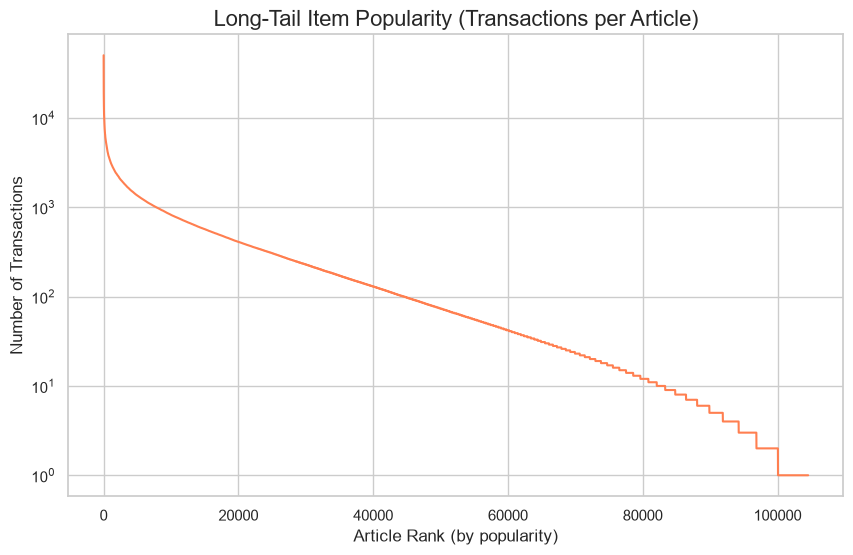

In [10]:
def plot_item_popularity_long_tail(transactions: pd.DataFrame) -> None:
    """
    Plot the long-tail distribution of item popularity (transactions per article).
    
    Args:
        transactions (pd.DataFrame): Transactions dataframe.
    """
    # Calculate transactions per article
    item_counts = transactions['article_id'].value_counts().values
    
    plt.figure(figsize=(10, 6))
    plt.plot(item_counts, color='coral')
    plt.title('Long-Tail Item Popularity (Transactions per Article)', fontsize=16)
    plt.xlabel('Article Rank (by popularity)', fontsize=12)
    plt.ylabel('Number of Transactions', fontsize=12)
    plt.yscale('log') # Log scale helps visualize the long tail better
    plt.show()

plot_item_popularity_long_tail(transactions_full)

**Insights & Recommendations:**
* **Insight:** Item popularity follows a steep long-tail distribution; a small fraction of items accounts for the vast majority of transactions.
* **Recommendation:** Popularity features will be highly predictive. To prevent training on dead SKUs, implement active-item sparsity filters (e.g., drop pair rows where `item_pop_30d` is zero) *after* feature engineering.


### 5.5 Overall Seasonal Trends

We analyze the number of transactions over time to identify seasonal patterns or trends.

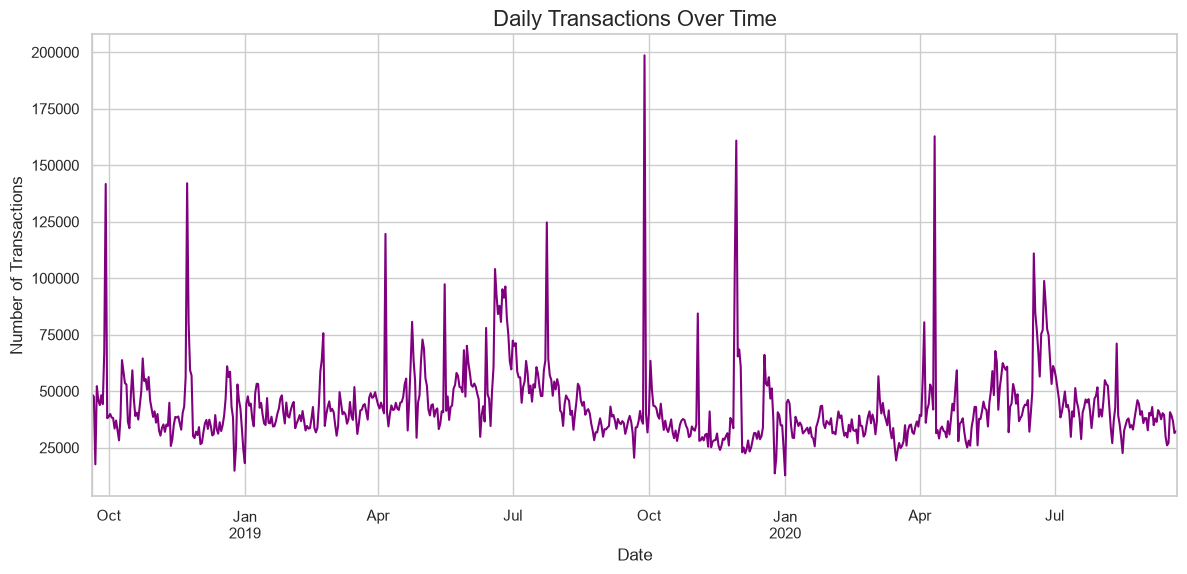

In [11]:
def plot_transactions_over_time(transactions: pd.DataFrame) -> None:
    """
    Plot the number of daily transactions over time.
    
    Args:
        transactions (pd.DataFrame): Transactions dataframe.
    """
    # Group by date and count transactions
    daily_txns = transactions.groupby('t_dat').size()
    
    plt.figure(figsize=(14, 6))
    daily_txns.plot(color='purple')
    plt.title('Daily Transactions Over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Transactions', fontsize=12)
    plt.show()

plot_transactions_over_time(transactions_full)

**Insights & Recommendations:**
* **Insight:** Daily transactions exhibit clear seasonality, periodic spikes, and temporal trends.
* **Recommendation:** Strict temporal framing is required. Use `snap_date` cutoffs where the feature cutoff and label window (e.g., 7 days forward) are strictly disjoint to prevent leakage. Include seasonal encodings like `txn_month_sin` and `txn_month_cos`.


---

## 6. Sample Validation

To ensure our sampled dataset (created in Notebook 0) is representative of the full dataset, we compare their distributions for key features.

### 6.1 Compare Age Distributions

We overlay the normalized age distributions of the full and sampled datasets.

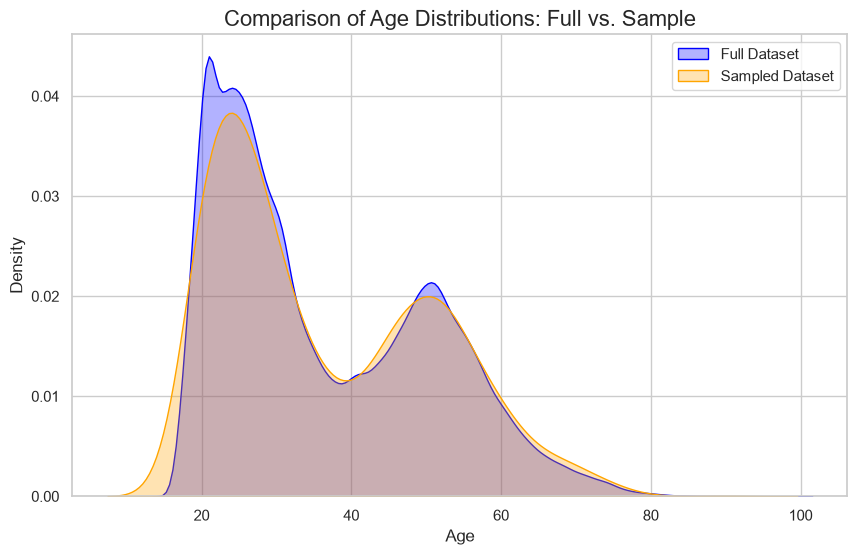

In [12]:
def compare_age_distributions(full_cust: pd.DataFrame, sample_cust: pd.DataFrame) -> None:
    """
    Plot and compare the age distributions of the full and sampled customer datasets.
    
    Args:
        full_cust (pd.DataFrame): Full customers dataframe.
        sample_cust (pd.DataFrame): Sampled customers dataframe.
    """
    plt.figure(figsize=(10, 6))
    sns.kdeplot(full_cust['age'].dropna(), label='Full Dataset', color='blue', fill=True, alpha=0.3)
    sns.kdeplot(sample_cust['age'].dropna(), label='Sampled Dataset', color='orange', fill=True, alpha=0.3)
    plt.title('Comparison of Age Distributions: Full vs. Sample', fontsize=16)
    plt.xlabel('Age', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.show()

compare_age_distributions(customers_full, customers_sample)

**Insights & Recommendations:**
* **Insight:** The normalized age distribution of the sample matches the full dataset closely.
* **Recommendation:** The stratified sampling strategy effectively preserves demographic representation. We can safely use the sample for iterative user-feature prototyping.


### 6.2 Compare Price Distributions

We compare the transaction prices to ensure the sample captures the same purchasing behavior.

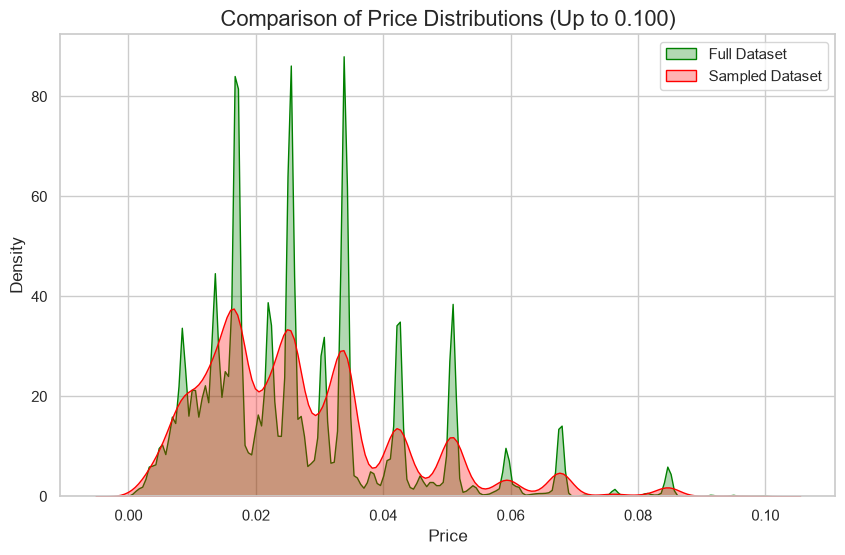

In [13]:
def compare_price_distributions(full_txn: pd.DataFrame, sample_txn: pd.DataFrame) -> None:
    """
    Plot and compare the price distributions of the full and sampled transaction datasets.
    
    Args:
        full_txn (pd.DataFrame): Full transactions dataframe.
        sample_txn (pd.DataFrame): Sampled transactions dataframe.
    """
    # Use a subset up to the 99th percentile for better visualization
    p99 = full_txn['price'].quantile(0.99)
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(full_txn[full_txn['price'] <= p99]['price'], label='Full Dataset', color='green', fill=True, alpha=0.3)
    sns.kdeplot(sample_txn[sample_txn['price'] <= p99]['price'], label='Sampled Dataset', color='red', fill=True, alpha=0.3)
    plt.title(f'Comparison of Price Distributions (Up to {p99:.3f})', fontsize=16)
    plt.xlabel('Price', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.show()

compare_price_distributions(transactions_full, transactions_sample)

**Insights & Recommendations:**
* **Insight:** The price distributions align well between the sample and the full dataset up to the 99th percentile.
* **Recommendation:** The sample accurately reflects the economic behavior of the overall population, making it suitable for price-based feature engineering.


### 6.3 Compare Category Popularity

We verify that the sampled transactions reflect the same category preferences as the full dataset.

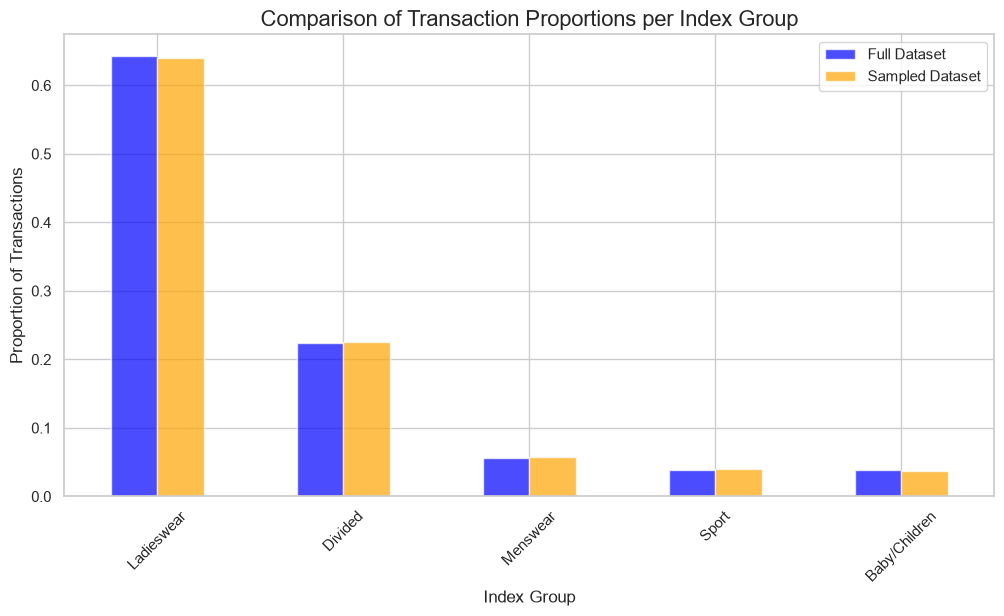

In [14]:
def compare_category_popularity(full_txn: pd.DataFrame, full_art: pd.DataFrame, 
                                sample_txn: pd.DataFrame, sample_art: pd.DataFrame) -> None:
    """
    Plot and compare the proportion of transactions per index group for both datasets.
    
    Args:
        full_txn (pd.DataFrame): Full transactions.
        full_art (pd.DataFrame): Full articles.
        sample_txn (pd.DataFrame): Sampled transactions.
        sample_art (pd.DataFrame): Sampled articles.
    """
    # Join transactions with articles to get index_group_name
    full_joined = full_txn[['article_id']].merge(full_art[['article_id', 'index_group_name']], on='article_id', how='left')
    sample_joined = sample_txn[['article_id']].merge(sample_art[['article_id', 'index_group_name']], on='article_id', how='left')
    
    # Calculate proportions
    full_props = full_joined['index_group_name'].value_counts(normalize=True).rename('Full Dataset')
    sample_props = sample_joined['index_group_name'].value_counts(normalize=True).rename('Sampled Dataset')
    
    # Combine for plotting
    props_df = pd.concat([full_props, sample_props], axis=1).fillna(0)
    
    props_df.plot(kind='bar', figsize=(12, 6), color=['blue', 'orange'], alpha=0.7)
    plt.title('Comparison of Transaction Proportions per Index Group', fontsize=16)
    plt.xlabel('Index Group', fontsize=12)
    plt.ylabel('Proportion of Transactions', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

compare_category_popularity(transactions_full, articles_full, transactions_sample, articles_sample)

**Insights & Recommendations:**
* **Insight:** The proportions of transactions per index group in the sample mirror the full dataset.
* **Recommendation:** The sample successfully captures category-level purchase behavior without introducing significant bias.


---

## 7. Preprocessing Strategies

Based on the unsupervised EDA, sample validation, and the project's pre-processing guidelines, we define the following strategies for subsequent pipelines and notebooks:

1. **Schema Normalization & Null Handling:**
   - **Dates:** Parse `t_dat` as date and normalize to calendar day.
   - **Customers (`age`):** Require `customer_id`. Cap implausible ages (e.g., below 16 or above 100), and z-score normalize for the two-tower model. Apply an explicit policy for missing ages (e.g., impute to a sentinel).
   - **Articles:** Drop rows where join keys (`article_id`) or critical category fields are null. Trim whitespace and unify casing on string categoricals.
   - **Transactions:** Confirm null counts on `t_dat`, `customer_id`, `article_id`, `price`. Drop unparseable dates.

2. **Outliers & Validity:**
   - **Price:** Drop rows with null, zero, or negative `price`. Winsorize transaction `price` at a high percentile (e.g., 99th) to reduce sensitivity to extreme prices before computing decayed price features.
   - **Deduplication:** Deduplicate exact repeats in transactions, but keep legitimate same-day multi-purchases as separate rows with a sequence ID.

3. **Sparsity & Active-Item Filters:**
   - **Dead SKUs:** Apply active-item filters *after* feature engineering. For example, drop ranking pair rows where `item_pop_30d` (or `item_pop_7d`) equals zero.
   - **Orphan Records:** Inner-join transactions to cleaned articles and customers; drop orphan transactions.

4. **Temporal Framing & Leakage Prevention:**
   - **Snap Dates:** Establish a strict `snap_date` schedule. The feature cutoff (`t_dat <= snap_date`) and the label window (e.g., `snap_date + 1` through `snap_date + 7`) must be strictly disjoint to prevent data leakage.
   - **Negative Sampling:** Generate window-aware negative samples (e.g., 1:5 ratio) per snap date. Sample articles the customer did *not* buy in the label window and did *not* previously purchase (seen exclusion).

5. **Feature Formatting:**
   - **Categoricals:** For XGBoost ranker, pass native categoricals (no target encoding in v1). For Two-Tower, build string-to-index vocabularies on training rows only.
   - **Imputation:** Use explicit default imputation for post-FE nulls (e.g., fill count features with 0, and cross-feature nulls with 0).


---

## 8. Final Overall Insights and Recommendations

**Overall Insights:**
* The unsupervised EDA highlights standard e-commerce traits: a slightly skewed demographic age distribution, heavy long-tail item popularity, and distinct temporal seasonality. 
* The stratified sample successfully mirrors the full dataset across key dimensions (age, price, and category popularity), confirming it is a robust, unbiased subset.

**Overall Recommendations for Next Steps:**
* **Proceed with Sample:** Utilize the validated sampled Parquet files for fast, iterative prototyping in Notebooks 2 through 6.
* **Implement Strict Data Cleaning:** Enforce the data typing, null dropping, and outlier winsorization strategies outlined in the Preprocessing Strategies section.
* **Avoid Leakage:** When moving to Notebook 2 (Temporal Framing and Labels), strictly adhere to the `snap_date` boundaries. Feature generation and label construction must not overlap temporally.
* **Apply Sparsity Filters:** Once features are generated in Notebook 3, ensure that inactive items (dead SKUs) are filtered out before ranking model training to optimize model performance and efficiency.
